# Length-Matched Numeric Reasoning Prompts

This notebook demonstrates the pipeline that builds the **Length-Matched Numeric Reasoning Prompts** dataset.

Starting from GSM8K grade-school arithmetic word problems, for each seed problem it generates 7 prompt variants:

- **1 bare-question control** (length tier 0)
- **2 content types** (`relevant`-elaboration vs `irrelevant`-filler) crossed with **3 length tiers** (short ~+75 tokens, medium ~+250 tokens, long ~+650 tokens over the control)

All variants are tokenized with `tiktoken` `cl100k_base` and length-matched within tolerance, so that relevant and filler prompts of the same tier have (almost) the same token count. This lets a downstream experiment isolate whether it's prompt *length* or prompt *content relevance* that changes an LLM's numeric-answer variance.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# tiktoken, loguru — NOT pre-installed on Colab, always install
_pip('tiktoken')
_pip('loguru')

# matplotlib — pre-installed on Colab, install locally at Colab's exact version
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import re
import sys
from pathlib import Path

import tiktoken
from loguru import logger

import matplotlib.pyplot as plt  # for the results visualization cell

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

ENC = tiktoken.get_encoding("cl100k_base")

## Load demo data

`mini_demo_data.json` is a curated subset of **24 raw GSM8K seed rows** (8 easy / 8 medium / 8 hard, bucketed by the number of `<<...>>` calculator annotations in the solution) in the original `{"question": ..., "answer": ...}` HuggingFace format — i.e. the *input* to the pipeline below, before any prompt-variant generation happens.

We try the GitHub-hosted copy first (for Colab), and fall back to the local file (for local runs).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-0e9809-interpretive-load-not-token-count-drives/main/round-1/dataset-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data)} raw GSM8K seed rows")
print(data[0])

Loaded 24 raw GSM8K seed rows
{'question': "Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?", 'answer': 'Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.\nShe makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.\n#### 18'}


## Config

All tunable parameters live here. `N_SEEDS` is set to the absolute minimum (3, i.e. 1 per difficulty bucket) to keep the demo fast; the original script used `N_SEEDS = 18` (6 per bucket) to produce the full 126-row dataset. Increase `N_SEEDS` (up to 24, the size of the mini seed pool) to scale the demo up.

In [5]:
# --- Config (all tunable parameters) ---
N_SEEDS = 3            # seeds to sample, balanced across easy/medium/hard (original script: 18)
TIER_TARGETS = {1: 75, 2: 250, 3: 650}  # extra-token targets for short/medium/long tiers (unchanged from original)
TOLERANCE_FRAC = 0.10
TOLERANCE_MIN_TOKENS = 15

## Filler pool, relevant-elaboration templates, and leakage-check vocabulary

Copied as-is from the original `data.py`: a fixed pool of 16 neutral topic sentences (zero digits, zero number-words) used to pad prompts with content that is irrelevant to the arithmetic; a set of generic task-pertinent "relevant elaboration" templates; and the vocabulary used to check that filler text hasn't accidentally leaked a number or overlapped with the seed's key entities.

In [6]:
NUMBER_WORDS = {
    "zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine",
    "ten", "eleven", "twelve", "thirteen", "fourteen", "fifteen", "sixteen",
    "seventeen", "eighteen", "nineteen", "twenty", "thirty", "forty", "fifty",
    "sixty", "seventy", "eighty", "ninety", "hundred", "thousand", "million",
    "billion", "half", "dozen", "first", "second", "third", "fourth", "fifth",
}
DIGIT_RE = re.compile(r"\d")

# Neutral filler topic pool: NO digits, NO number-words, NO math vocabulary.
FILLER_SENTENCES = [
    "The migration patterns of monarch butterflies span thousands of miles across "
    "generations, with individual insects never completing the round trip themselves.",
    "Cumulus clouds form when warm air rises and cools, condensing water vapor into "
    "visible droplets that drift lazily across an open sky.",
    "The city of Kyoto served as the imperial capital for centuries before the seat "
    "of government eventually relocated to Tokyo during a period of rapid modernization.",
    "Sourdough bread relies on a wild yeast starter that must be fed regularly with "
    "flour and water to keep its microbial culture active and healthy.",
    "Coastal fog rolls in in the early evening, blanketing the hillside vineyards in "
    "a cool mist that lingers until the following late morning.",
    "The lighthouse keeper maintained a strict routine, polishing the lens each "
    "evening and logging the weather in a worn leather notebook by lamplight.",
    "Traditional woodworking joints, such as the dovetail, were prized for their "
    "strength because they require no metal fasteners to hold securely together.",
    "The orchestra rehearsed in an old converted warehouse, its brick walls giving "
    "the strings a warm, resonant tone that the musicians came to love.",
    "Desert plants like the saguaro cactus store water in their thick, ribbed stems, "
    "allowing them to survive long stretches without any rainfall at all.",
    "The train wound slowly through the mountain pass, offering passengers glimpses "
    "of pine forests and distant ridgelines wrapped in drifting cloud.",
    "Beekeepers often wear light-colored clothing because darker hues can trigger a "
    "defensive response from a hive that mistakes the wearer for a predator.",
    "The tide pools along the rocky shoreline teemed with anemones, hermit crabs, "
    "and small darting fish that had been stranded by the receding water.",
    "Handmade paper is traditionally pressed from pulped fibers of mulberry bark, "
    "then dried on frames in the sun until the sheets become crisp and light.",
    "The archivist spent her afternoons cataloguing brittle letters, carefully "
    "noting the ink type and paper stock before sealing each page in an acid-free sleeve.",
    "Wind farms are often sited along coastal ridgelines where steady onshore "
    "breezes provide a more reliable source of turning force for the turbine blades.",
    "The potter centered the clay on the wheel, applying steady pressure with damp "
    "hands until the spinning mass rose smoothly into a narrow, even cylinder.",
]

MATH_TOPIC_WORDS = {"eggs", "dollars", "dollar", "money", "price", "cost", "buy", "sell",
                     "total", "each", "per", "number", "count", "how", "many", "much"}

RELEVANT_TEMPLATES = [
    "Before answering, restate the problem carefully: {question}",
    "Note the key quantities given in the problem and consider each step in turn "
    "before computing the final total. Work through the setup deliberately.",
    "Make sure to account for every quantity mentioned, and double-check that units "
    "are consistent (e.g. dollars, items, or counts) before combining any numbers.",
    "Recall that intermediate results should be computed one operation at a time; "
    "verify each intermediate value makes sense in context before proceeding to the next.",
    "Consider whether any quantity described is a rate (per day, per item, per person) "
    "that must be multiplied or divided appropriately rather than added directly.",
    "As a sanity check, confirm that the final quantity you compute matches the units "
    "and scale implied by the question being asked.",
]

## Seed loading + balanced sampling

`gsm8k_seeds` mirrors the original function, but reads from the `data` variable we loaded above instead of a local file, and buckets each seed into easy/medium/hard by the number of `<<...>>` calculator annotations in its solution. `pick_balanced` then samples `N_SEEDS` seeds as evenly as possible across the three buckets, deterministically.

In [7]:
def gsm8k_seeds(raw: list[dict]) -> list[dict]:
    seeds = []
    for i, row in enumerate(raw):
        q, a = row["question"], row["answer"]
        if "####" not in a:
            continue
        gold = a.split("####")[-1].strip().replace(",", "")
        try:
            float(gold)
        except ValueError:
            continue
        n_steps = len(re.findall(r"<<[^>]*>>", a))
        bucket = "easy" if n_steps <= 2 else ("medium" if n_steps == 3 else "hard")
        seeds.append({
            "seed_id": f"gsm8k_{i}",
            "question": q,
            "gold_answer": gold,
            "difficulty_bucket": bucket,
            "n_steps": n_steps,
            "source_dataset": "openai/gsm8k",
        })
    return seeds


def pick_balanced(seeds: list[dict], n: int) -> list[dict]:
    """Sample ~evenly across difficulty buckets, deterministic order."""
    buckets = {"easy": [], "medium": [], "hard": []}
    for s in seeds:
        buckets[s["difficulty_bucket"]].append(s)
    per = n // 3
    chosen = []
    for b in ("easy", "medium", "hard"):
        chosen.extend(buckets[b][:per])
    remainder = n - len(chosen)
    if remainder > 0:
        pool = [s for b in buckets.values() for s in b[per:]]
        chosen.extend(pool[:remainder])
    return chosen[:n]


gsm8k_all = gsm8k_seeds(data)
gsm8k_picked = pick_balanced(gsm8k_all, N_SEEDS)
logger.info(f"GSM8K candidates: {len(gsm8k_all)} | picked: {len(gsm8k_picked)}")
[s["difficulty_bucket"] for s in gsm8k_picked]

16:07:04|INFO   |GSM8K candidates: 24 | picked: 3


['easy', 'medium', 'hard']

## Length-matched variant generation

For each picked seed, `build_examples_for_seed` builds: the bare-question control, plus for each tier a `relevant` prompt (question + task-scaffolding elaboration) and a `filler` prompt (question + neutral off-topic sentences), both padded/trimmed via `tiktoken` to land within tolerance of the tier's extra-token target.

In [8]:
def n_tokens(text: str) -> int:
    return len(ENC.encode(text))


def build_filler(target_extra_tokens: int, seed_key_terms: set[str]) -> str:
    """Concatenate filler sentences (skipping any with vocabulary overlap) until
    the token budget is reached, then trim to the target via tiktoken decode."""
    pool = [s for s in FILLER_SENTENCES
            if not (seed_key_terms & {w.lower().strip(".,'\"") for w in s.split()})]
    text = ""
    idx = 0
    while n_tokens(text) < target_extra_tokens and idx < 500:
        text = (text + " " + pool[idx % len(pool)]).strip()
        idx += 1
    toks = ENC.encode(text)
    if len(toks) > target_extra_tokens:
        toks = toks[:target_extra_tokens]
        text = ENC.decode(toks)
    return text


def build_relevant(target_extra_tokens: int, question: str) -> str:
    text = RELEVANT_TEMPLATES[0].format(question=question)
    idx = 1
    while n_tokens(text) < target_extra_tokens and idx < 200:
        text = (text + " " + RELEVANT_TEMPLATES[idx % len(RELEVANT_TEMPLATES)]).strip()
        idx += 1
    toks = ENC.encode(text)
    if len(toks) > target_extra_tokens:
        toks = toks[:target_extra_tokens]
        text = ENC.decode(toks)
    return text


def has_numeric_leakage(text: str) -> bool:
    if DIGIT_RE.search(text):
        return True
    words = {w.lower().strip(".,'\"()") for w in text.split()}
    return bool(words & NUMBER_WORDS)


def key_entities(question: str) -> set[str]:
    words = {w.lower().strip(".,'\"()?") for w in question.split()}
    return {w for w in words if len(w) > 3 and w not in MATH_TOPIC_WORDS}


def build_examples_for_seed(seed: dict) -> list[dict]:
    q = seed["question"]
    control_tokens = n_tokens(q)
    rows = []

    rows.append({
        "input": q,
        "output": seed["gold_answer"],
        "metadata_seed_id": seed["seed_id"],
        "metadata_content_type": "control",
        "metadata_length_tier": 0,
        "metadata_token_count": control_tokens,
        "metadata_source_dataset": seed["source_dataset"],
        "metadata_difficulty_bucket": seed["difficulty_bucket"],
        "metadata_leakage_check_passed": True,
    })

    key_terms = key_entities(q)

    for tier, extra in TIER_TARGETS.items():
        tol = max(TOLERANCE_MIN_TOKENS, int(extra * TOLERANCE_FRAC))

        relevant_extra = build_relevant(extra, q)
        relevant_prompt = f"{relevant_extra}\n\n{q}"
        rel_tokens = n_tokens(relevant_prompt) - control_tokens

        filler_extra = build_filler(extra, key_terms)
        filler_prompt = f"{filler_extra}\n\n{q}"
        fil_tokens = n_tokens(filler_prompt) - control_tokens

        leakage = has_numeric_leakage(filler_extra)
        overlap = bool(key_terms & {w.lower().strip(".,'\"") for w in filler_extra.split()})
        passed = (not leakage) and (not overlap)

        rows.append({
            "input": relevant_prompt,
            "output": seed["gold_answer"],
            "metadata_seed_id": seed["seed_id"],
            "metadata_content_type": "relevant",
            "metadata_length_tier": tier,
            "metadata_token_count": n_tokens(relevant_prompt),
            "metadata_target_extra_tokens": extra,
            "metadata_actual_extra_tokens": rel_tokens,
            "metadata_tolerance_tokens": tol,
            "metadata_within_tolerance": abs(rel_tokens - extra) <= tol,
            "metadata_source_dataset": seed["source_dataset"],
            "metadata_difficulty_bucket": seed["difficulty_bucket"],
            "metadata_leakage_check_passed": True,
        })
        rows.append({
            "input": filler_prompt,
            "output": seed["gold_answer"],
            "metadata_seed_id": seed["seed_id"],
            "metadata_content_type": "filler",
            "metadata_length_tier": tier,
            "metadata_token_count": n_tokens(filler_prompt),
            "metadata_target_extra_tokens": extra,
            "metadata_actual_extra_tokens": fil_tokens,
            "metadata_tolerance_tokens": tol,
            "metadata_within_tolerance": abs(fil_tokens - extra) <= tol,
            "metadata_source_dataset": seed["source_dataset"],
            "metadata_difficulty_bucket": seed["difficulty_bucket"],
            "metadata_leakage_check_passed": passed,
        })
    return rows

## Build the dataset

Run the generator over the picked seeds and assemble the final `datasets_out` structure, exactly matching the shape of `full_data_out.json`.

In [9]:
examples = []
for seed in gsm8k_picked:
    examples.extend(build_examples_for_seed(seed))

n_leak_fail = sum(1 for e in examples if not e["metadata_leakage_check_passed"])
n_tol_fail = sum(1 for e in examples
                  if "metadata_within_tolerance" in e and not e["metadata_within_tolerance"])
logger.info(f"gsm8k_length_matched: {len(examples)} examples | leakage failures: {n_leak_fail} | "
            f"tolerance failures: {n_tol_fail}")

out = {
    "metadata": {
        "description": "GSM8K seeded numeric-reasoning prompts, expanded into "
                        "relevant-elaboration and irrelevant-filler variants at 3 "
                        "token-matched length tiers plus a bare-question control.",
        "tokenizer": "tiktoken cl100k_base",
        "tier_targets_extra_tokens": TIER_TARGETS,
        "tolerance_frac": TOLERANCE_FRAC,
        "tolerance_min_tokens": TOLERANCE_MIN_TOKENS,
    },
    "datasets": [{"dataset": "gsm8k_length_matched", "examples": examples}],
}
print(f"Built {len(examples)} total examples")

16:07:04|INFO   |gsm8k_length_matched: 21 examples | leakage failures: 0 | tolerance failures: 0


Built 21 total examples


## Results

A quick summary table of the generated examples, plus a plot showing how closely the `relevant` and `filler` variants hit their target extra-token budgets per tier — the length-matching this dataset is built around.

seed_id      content_type tier  tokens   gold  
gsm8k_0      control    0     64       18    
gsm8k_0      relevant   1     140      18    
gsm8k_0      filler     1     140      18    
gsm8k_0      relevant   2     315      18    
gsm8k_0      filler     2     315      18    
gsm8k_0      relevant   3     715      18    
gsm8k_0      filler     3     715      18    
gsm8k_8      control    0     41       260   
gsm8k_8      relevant   1     117      260   
gsm8k_8      filler     1     117      260   
gsm8k_8      relevant   2     292      260   
gsm8k_8      filler     2     292      260   
gsm8k_8      relevant   3     692      260   
gsm8k_8      filler     3     692      260   
gsm8k_16     control    0     49       70000 
gsm8k_16     relevant   1     125      70000 
gsm8k_16     filler     1     125      70000 
gsm8k_16     relevant   2     300      70000 
gsm8k_16     filler     2     300      70000 
gsm8k_16     relevant   3     699      70000 
gsm8k_16     filler     3     70

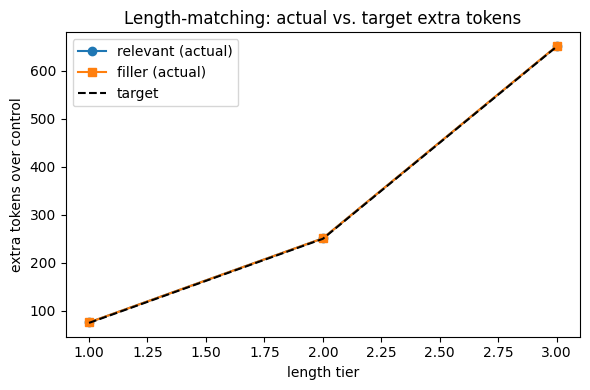

In [10]:
print(f"{'seed_id':<12} {'content_type':<10} {'tier':<5} {'tokens':<8} {'gold':<6}")
for e in examples:
    print(f"{e['metadata_seed_id']:<12} {e['metadata_content_type']:<10} "
          f"{e['metadata_length_tier']:<5} {e['metadata_token_count']:<8} {e['output']:<6}")

# Plot actual vs. target extra tokens per tier, split by content type
tiers = sorted(TIER_TARGETS.keys())
fig, ax = plt.subplots(figsize=(6, 4))
for content_type, marker in (("relevant", "o"), ("filler", "s")):
    xs, ys = [], []
    for tier in tiers:
        vals = [e["metadata_actual_extra_tokens"] for e in examples
                 if e["metadata_content_type"] == content_type and e["metadata_length_tier"] == tier]
        if vals:
            xs.append(tier)
            ys.append(sum(vals) / len(vals))
    ax.plot(xs, ys, marker=marker, label=f"{content_type} (actual)")
ax.plot(tiers, [TIER_TARGETS[t] for t in tiers], "k--", label="target")
ax.set_xlabel("length tier")
ax.set_ylabel("extra tokens over control")
ax.set_title("Length-matching: actual vs. target extra tokens")
ax.legend()
plt.tight_layout()
plt.show()